First:
What does the dataset look like?

Second:
Is the target balanced?

Third:
How are the main numerical measurements distributed?

Fourth:
Which patient characteristics differ between heart-disease and non-heart-disease cases?

Fifth:
Which categorical/medical conditions show strong target differences?

Sixth:
What do correlations tell us?

Seventh:
Are there strange/missing/outlier values?

Finally:
Which features appear most interesting for supervised learning?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data + quick overview: 

First I load the cleaned dataset and check its size and descriptive statistics.

The dataset contains 50,000 rows and 21 columns. `Heart_Disease` is the target column.

In [2]:
df = pd.read_csv(r"C:\Users\Masters Computer\Desktop\VScode_For_ Python\internship\project1\Data\synthetic_heart_disease_dataset.csv", keep_default_na=False)

In [3]:
print(df.shape)
df.describe()

(50000, 21)


,Age,Weight,Height,BMI,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.46406,84.547520,174.460000,28.984284,0.299620,0.199260,0.251660,0.400500,0.099280,139.299580,89.528800,84.449560,124.493020,224.556360,0.463460
std,14.43809,20.213257,14.420379,6.367494,0.458096,0.399448,0.433971,0.490005,0.299041,23.083544,17.258063,14.491325,31.691507,43.157467,0.498668
min,30.00000,50.000000,150.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,60.000000,60.000000,70.000000,150.000000,0.000000
25%,42.00000,67.000000,162.000000,23.500000,0.000000,0.000000,0.000000,0.000000,0.000000,119.000000,75.000000,72.000000,97.000000,187.000000,0.000000
50%,54.00000,85.000000,174.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.000000,90.000000,85.000000,125.000000,225.000000,0.000000
75%,67.00000,102.000000,187.000000,34.500000,1.000000,0.000000,1.000000,1.000000,0.000000,159.000000,104.000000,97.000000,152.000000,262.000000,1.000000
max,79.00000,119.000000,199.000000,40.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179.000000,119.000000,109.000000,179.000000,299.000000,1.000000


### Target class proportions:

In [4]:
print("Heart disease Count-proportions:\n")
print(df["Heart_Disease"].value_counts(normalize=True))

Heart disease Count-proportions:

Heart_Disease
0    0.53654
1    0.46346
Name: proportion, dtype: float64


The target variable is reasonably balanced, with approximately 54% of observations belonging to class 0 and 46% to class 1. Therefore, severe class imbalance is not present.

C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\3879300911.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.countplot( data=df , x = 'Heart_Disease', palette= 'colorblind', edgecolor = 'black')


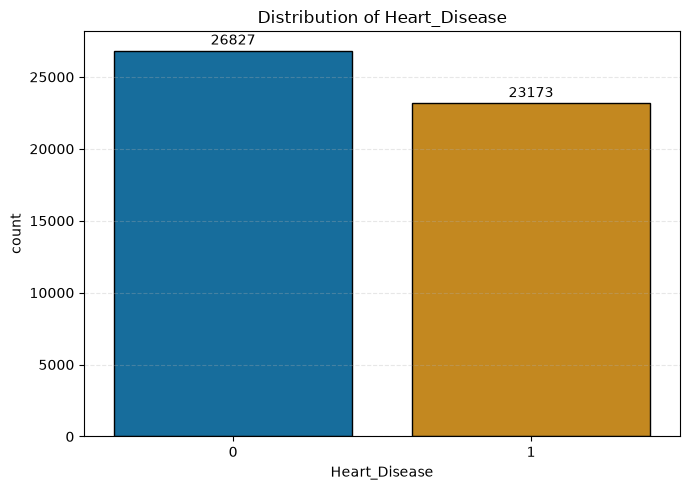

In [5]:
plt.figure(figsize = (7,5))
ax= sns.countplot( data=df , x = 'Heart_Disease', palette= 'colorblind', edgecolor = 'black')

# show the value in top of each box
for container in ax.containers:
    ax.bar_label(container, padding=2)
    
plt.title('Distribution of Heart_Disease')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


### Feature distributions:

- Here I check how the numerical and categorical features are distributed.

- For numerical features with many values I use histograms, while binary/discrete numerical features are easier to read with count plots.

#### Numerical distributions:

- Classes with continues data (many unique values) are made into histograms.

- Classes which are Discrete numeric / categorical numeric are made into Countplot.

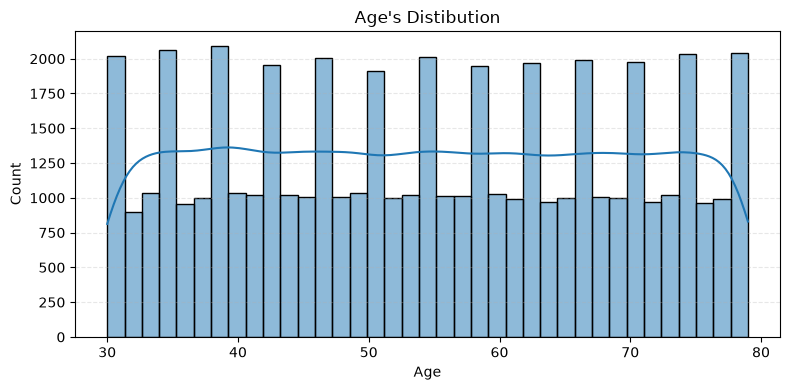

Age's discribtive statistics: 
count    50000.00000
mean        54.46406
std         14.43809
min         30.00000
25%         42.00000
50%         54.00000
75%         67.00000
max         79.00000
Name: Age, dtype: float64


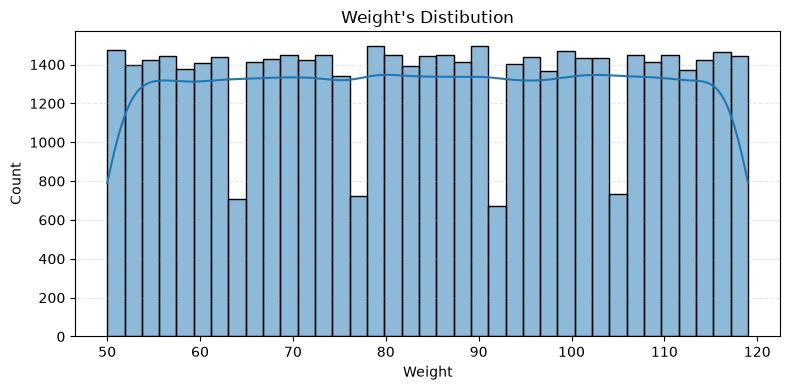

Weight's discribtive statistics: 
count    50000.000000
mean        84.547520
std         20.213257
min         50.000000
25%         67.000000
50%         85.000000
75%        102.000000
max        119.000000
Name: Weight, dtype: float64


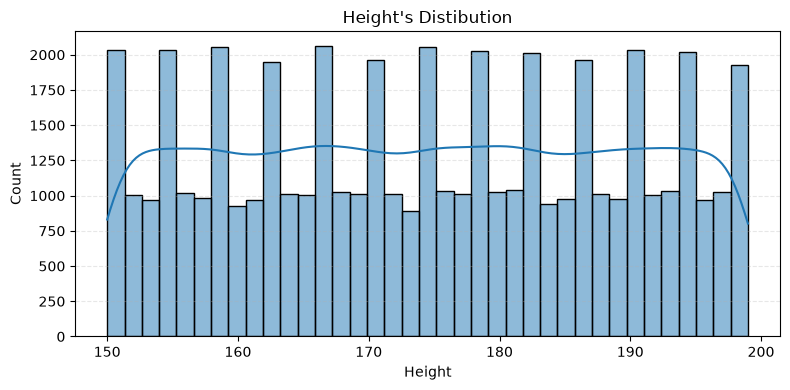

Height's discribtive statistics: 
count    50000.000000
mean       174.460000
std         14.420379
min        150.000000
25%        162.000000
50%        174.000000
75%        187.000000
max        199.000000
Name: Height, dtype: float64


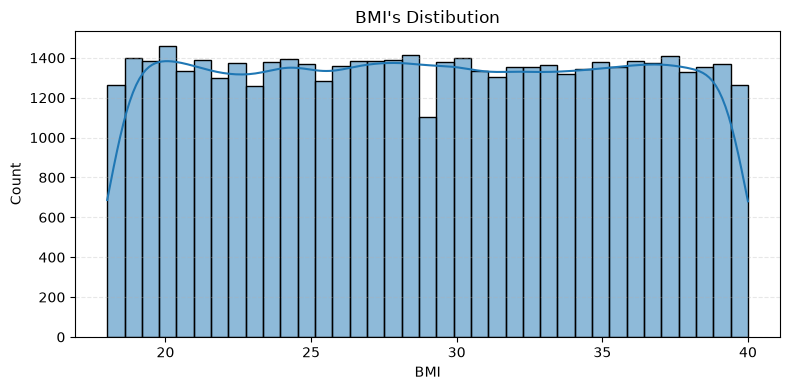

BMI's discribtive statistics: 
count    50000.000000
mean        28.984284
std          6.367494
min         18.000000
25%         23.500000
50%         29.000000
75%         34.500000
max         40.000000
Name: BMI, dtype: float64


C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\344538157.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[val], palette= 'colorblind',edgecolor = 'black')


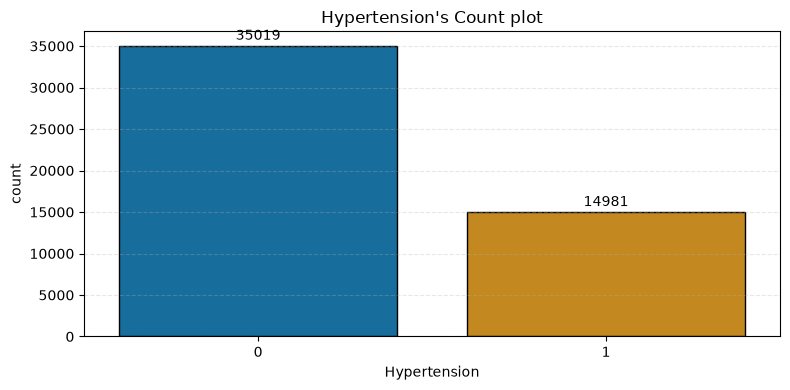

Hypertension's discribtive statistics: 
count    50000.000000
mean         0.299620
std          0.458096
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Hypertension, dtype: float64


C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\344538157.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[val], palette= 'colorblind',edgecolor = 'black')


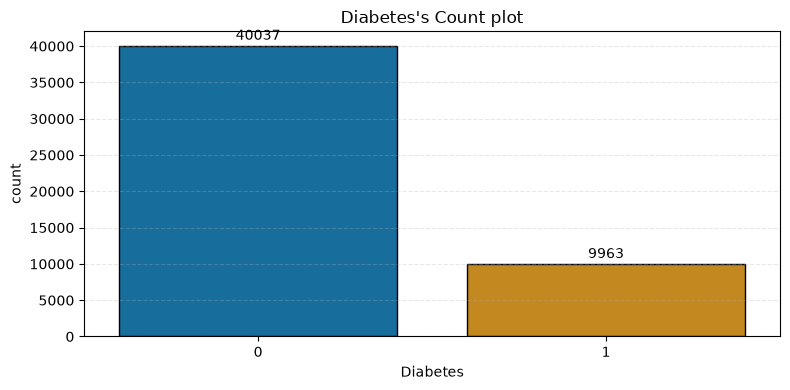

Diabetes's discribtive statistics: 
count    50000.000000
mean         0.199260
std          0.399448
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Diabetes, dtype: float64


C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\344538157.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[val], palette= 'colorblind',edgecolor = 'black')


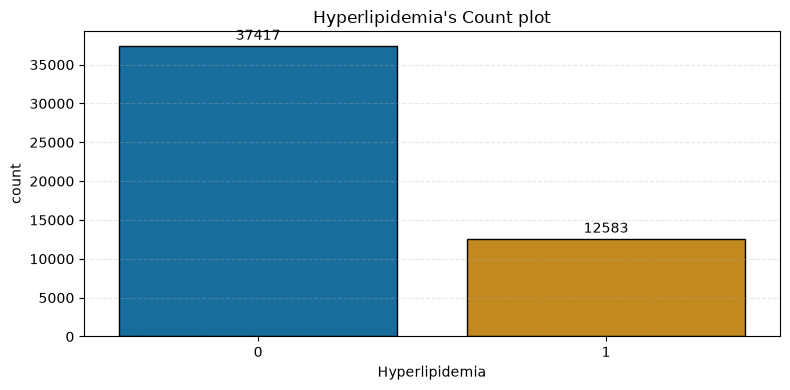

Hyperlipidemia's discribtive statistics: 
count    50000.000000
mean         0.251660
std          0.433971
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Hyperlipidemia, dtype: float64


C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\344538157.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[val], palette= 'colorblind',edgecolor = 'black')


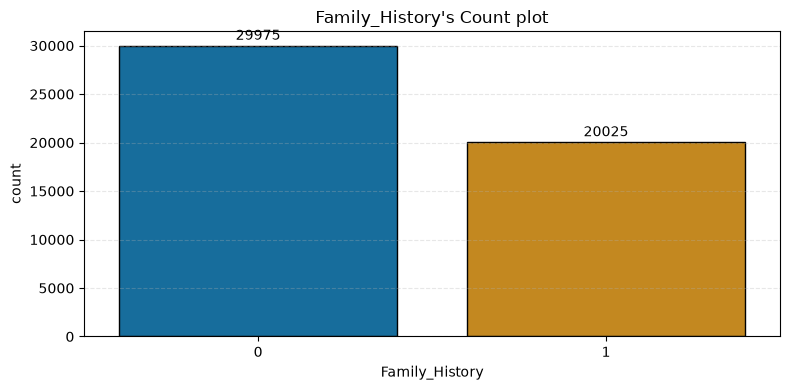

Family_History's discribtive statistics: 
count    50000.000000
mean         0.400500
std          0.490005
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Family_History, dtype: float64


C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\344538157.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[val], palette= 'colorblind',edgecolor = 'black')


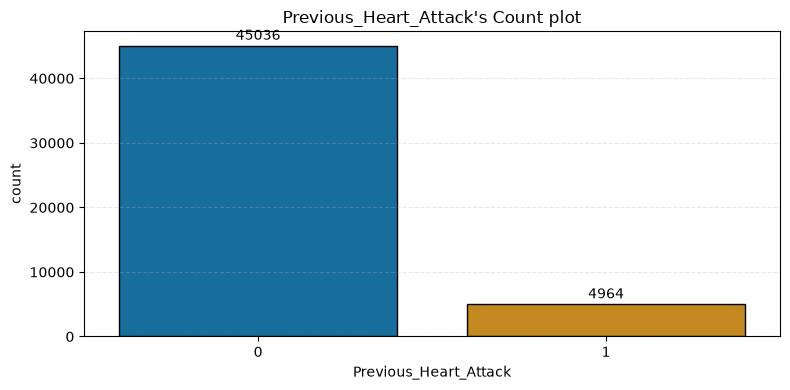

Previous_Heart_Attack's discribtive statistics: 
count    50000.000000
mean         0.099280
std          0.299041
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Previous_Heart_Attack, dtype: float64


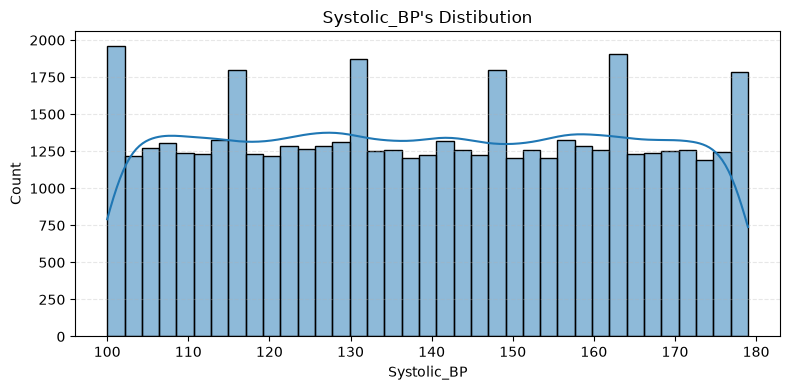

Systolic_BP's discribtive statistics: 
count    50000.000000
mean       139.299580
std         23.083544
min        100.000000
25%        119.000000
50%        139.000000
75%        159.000000
max        179.000000
Name: Systolic_BP, dtype: float64


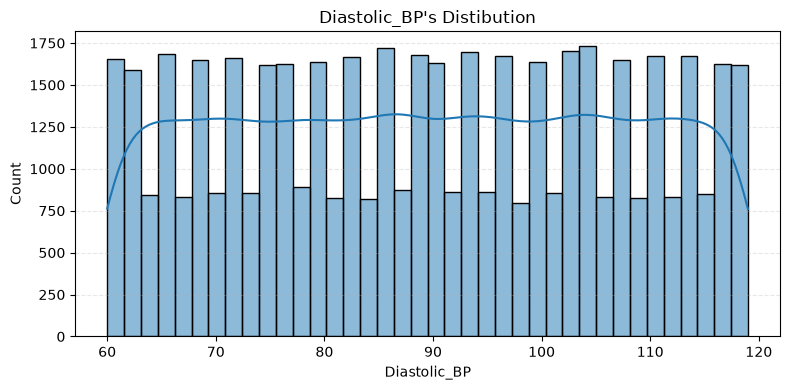

Diastolic_BP's discribtive statistics: 
count    50000.000000
mean        89.528800
std         17.258063
min         60.000000
25%         75.000000
50%         90.000000
75%        104.000000
max        119.000000
Name: Diastolic_BP, dtype: float64


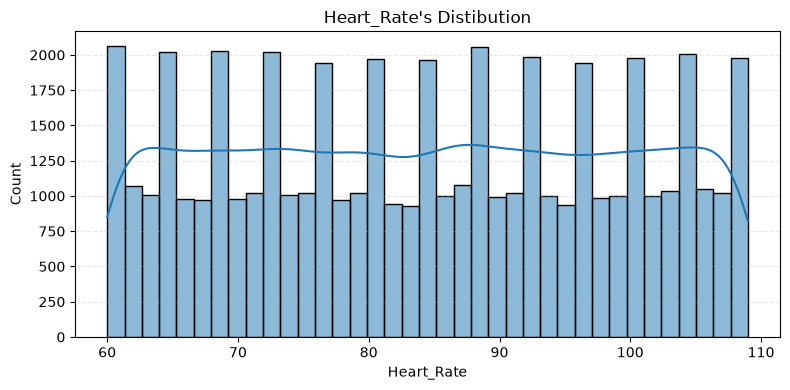

Heart_Rate's discribtive statistics: 
count    50000.000000
mean        84.449560
std         14.491325
min         60.000000
25%         72.000000
50%         85.000000
75%         97.000000
max        109.000000
Name: Heart_Rate, dtype: float64


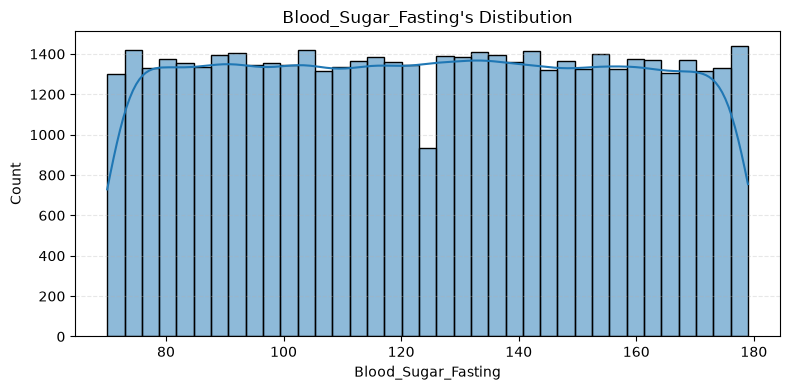

Blood_Sugar_Fasting's discribtive statistics: 
count    50000.000000
mean       124.493020
std         31.691507
min         70.000000
25%         97.000000
50%        125.000000
75%        152.000000
max        179.000000
Name: Blood_Sugar_Fasting, dtype: float64


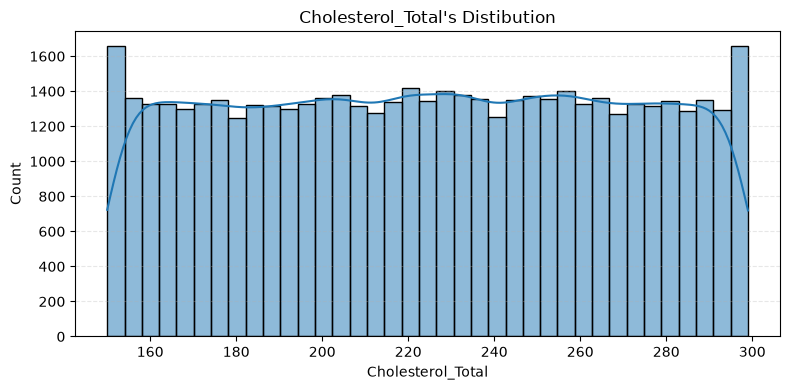

Cholesterol_Total's discribtive statistics: 
count    50000.000000
mean       224.556360
std         43.157467
min        150.000000
25%        187.000000
50%        225.000000
75%        262.000000
max        299.000000
Name: Cholesterol_Total, dtype: float64


C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\344538157.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df[val], palette= 'colorblind',edgecolor = 'black')


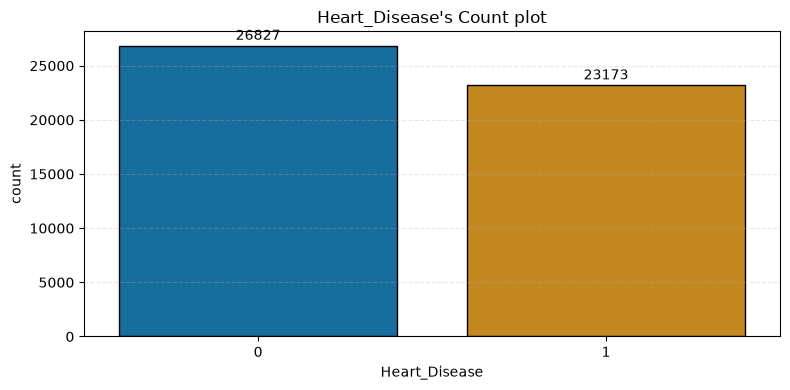

Heart_Disease's discribtive statistics: 
count    50000.000000
mean         0.463460
std          0.498668
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Heart_Disease, dtype: float64


In [16]:
# SEPERATE NUMERICAL - CATEGORICAL
categorical_cols = df.select_dtypes(include=['str']).columns.tolist() # to use in the next
numerical_cols = df.select_dtypes(include=['int64','float64']).columns.tolist() # to use now 


for val in numerical_cols:
    plt.figure(figsize=(8,4))
    
    if df[val].nunique() > 10: # numerical distributions with continuous data 
        sns.histplot(df[val], edgecolor = 'black', kde= True)
        plt.title(f"{val}'s Distibution")
        
    else: # Categorical numeric (0 - 1 and such..)
        ax = sns.countplot(x=df[val], palette= 'colorblind',edgecolor = 'black')
        plt.title((f"{val}'s Count plot"))
        
        for container in ax.containers:
            ax.bar_label(container, padding=2)
    
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()  
    
    print(f"{val}'s discribtive statistics: ")
    print(df[val].describe())  

#### Categorical distributions:

- The categorical features are checked using count plots and proportions.

- This helps show whether some categories are much more common than others before comparing them with the target.

C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\3381560744.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x= df[col], palette= 'colorblind',edgecolor = 'black')


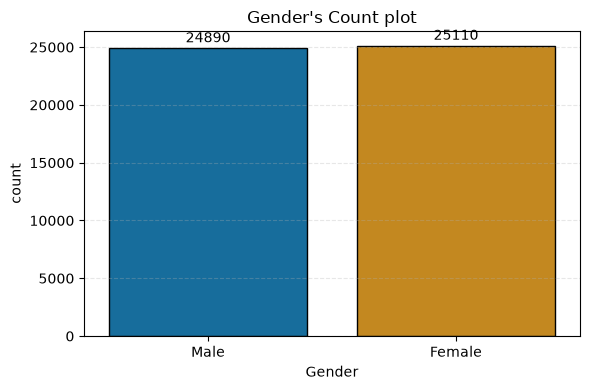

C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\3381560744.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x= df[col], palette= 'colorblind',edgecolor = 'black')


Gender's proportions: 
Gender
Female    0.5022
Male      0.4978
Name: proportion, dtype: float64


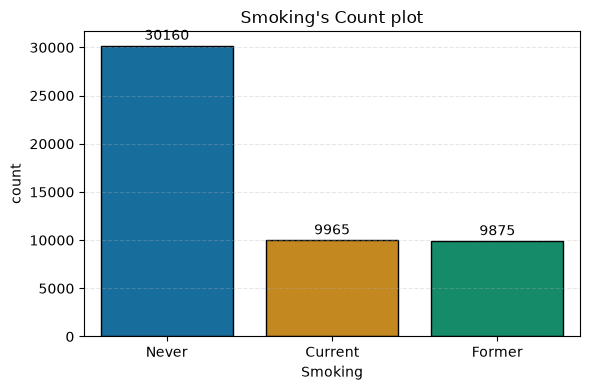

Smoking's proportions: 
Smoking
Never      0.6032
Current    0.1993
Former     0.1975
Name: proportion, dtype: float64


C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\3381560744.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x= df[col], palette= 'colorblind',edgecolor = 'black')


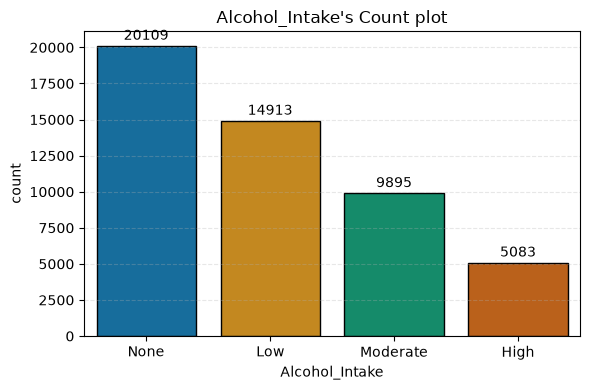

Alcohol_Intake's proportions: 
Alcohol_Intake
None        0.40218
Low         0.29826
Moderate    0.19790
High        0.10166
Name: proportion, dtype: float64


C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\3381560744.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x= df[col], palette= 'colorblind',edgecolor = 'black')


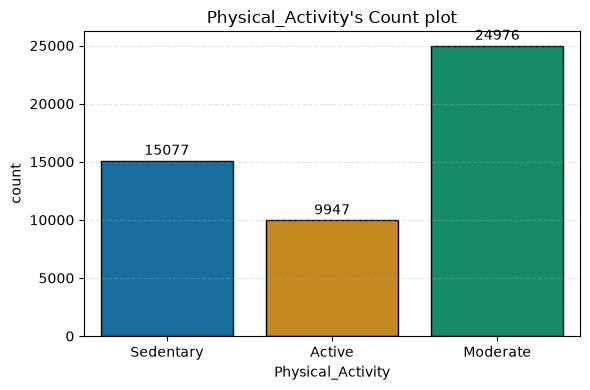

Physical_Activity's proportions: 
Physical_Activity
Moderate     0.49952
Sedentary    0.30154
Active       0.19894
Name: proportion, dtype: float64


C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\3381560744.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x= df[col], palette= 'colorblind',edgecolor = 'black')


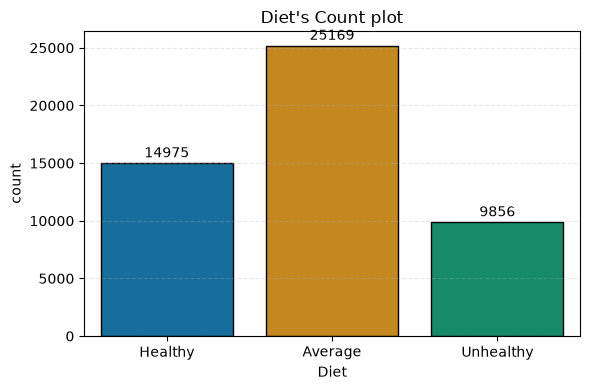

Diet's proportions: 
Diet
Average      0.50338
Healthy      0.29950
Unhealthy    0.19712
Name: proportion, dtype: float64


C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\3381560744.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x= df[col], palette= 'colorblind',edgecolor = 'black')


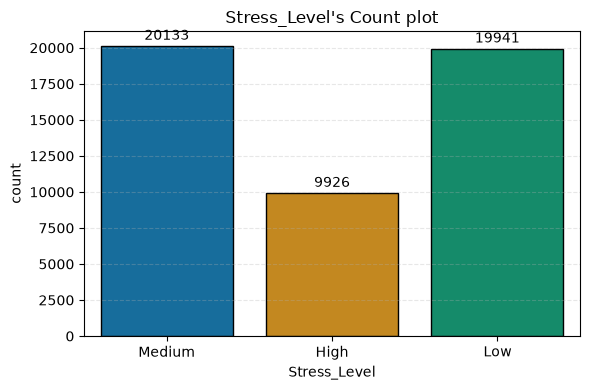

Stress_Level's proportions: 
Stress_Level
Medium    0.40266
Low       0.39882
High      0.19852
Name: proportion, dtype: float64


In [18]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    
    ax = sns.countplot(x= df[col], palette= 'colorblind',edgecolor = 'black')
    plt.title(f"{col}'s Count plot")
        
    for container in ax.containers:
        ax.bar_label(container, padding=2)
    
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()  
    
    
    print (f"{col}'s proportions: ")
    print (df[col].value_counts(normalize= True))

### Feature vs target relationships:

- Numerical feature vs Heart_Disease distributions:

- Box plots grouped by Heart_Disease.

- Bar plots for positive heart disease rate among binary medical categories

#### Age vs Heart_Disease: 

This comparison checks whether the age distribution is different between patients with and without heart disease.

Do patients with heart disease tend to be older?

C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\3540974369.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Heart_Disease', y='Age', palette='crest') # age grouped by Heart_Disease


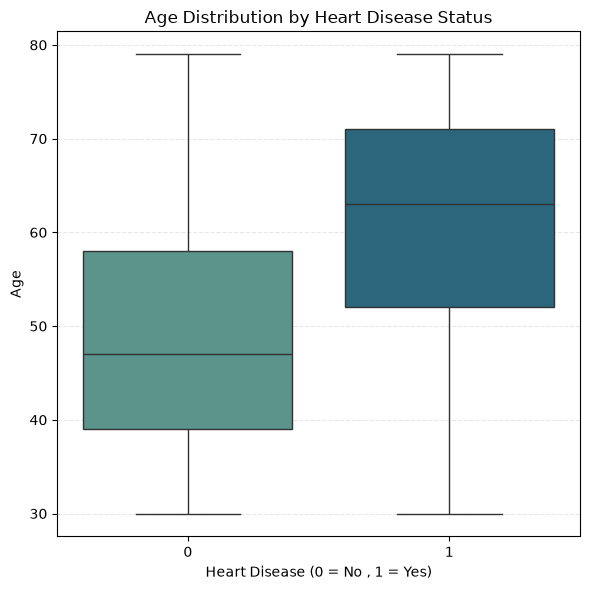

Mean 'Age' for Heart_Disease categories: 
Heart_Disease
0    49.363030
1    60.369439
Name: Age, dtype: float64 



In [23]:
plt.figure(figsize = (6,6))
sns.boxplot(data=df, x='Heart_Disease', y='Age', palette='crest') # age grouped by Heart_Disease

plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No , 1 = Yes)') 

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("Mean 'Age' for Heart_Disease categories: ")
print(df.groupby('Heart_Disease')['Age'].agg("mean"),"\n")

#### Cholesterol_Total vs Heart_Disease:

This comparison checks whether total cholesterol differs between the two target classes.

C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\143276149.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Heart_Disease', y='Cholesterol_Total', palette='flare') # age grouped by Heart_Disease


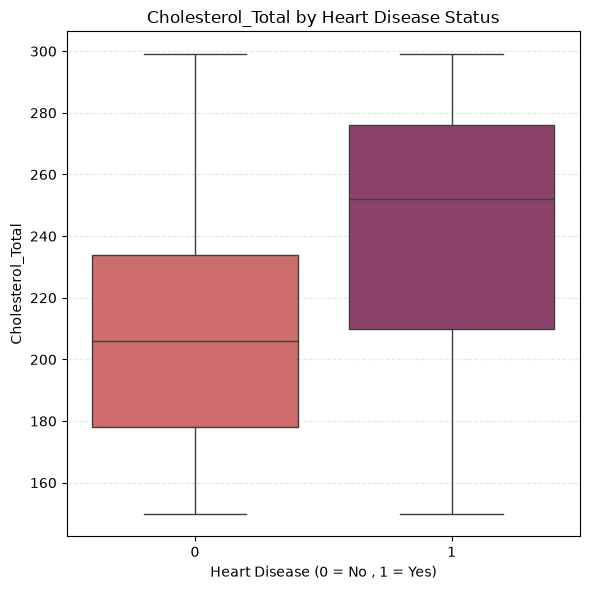

Mean 'Total Cholesterol level' for Heart_Disease categories: 
Heart_Disease
0    209.551683
1    241.927027
Name: Cholesterol_Total, dtype: float64 



In [22]:
plt.figure(figsize = (6,6))
sns.boxplot(data=df, x='Heart_Disease', y='Cholesterol_Total', palette='flare') # age grouped by Heart_Disease

plt.title('Cholesterol_Total by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No , 1 = Yes)') 

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("Mean 'Total Cholesterol level' for Heart_Disease categories: ")
print(df.groupby('Heart_Disease')['Cholesterol_Total'].agg("mean"),"\n")

#### BMI vs Heart_Disease: (weak relation)

Here I check whether BMI has a visible difference between the two target classes.

C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\2771638918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Heart_Disease', y='BMI', palette='colorblind') # age grouped by Heart_Disease


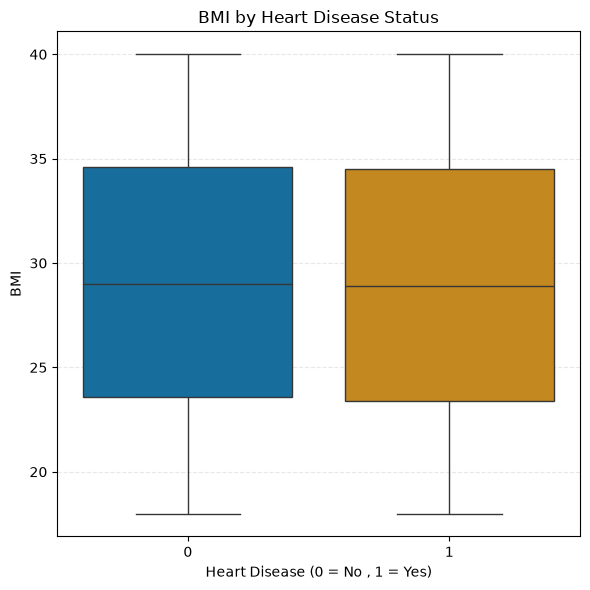

Mean 'BMI' for Heart_Disease categories: 
Heart_Disease
0    29.023219
1    28.939209
Name: BMI, dtype: float64 



In [25]:
plt.figure(figsize = (6,6))
sns.boxplot(data=df, x='Heart_Disease', y='BMI', palette='colorblind') # age grouped by Heart_Disease

plt.title('BMI by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No , 1 = Yes)') 

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("Mean 'BMI' for Heart_Disease categories: ")
print(df.groupby('Heart_Disease')['BMI'].agg("mean"),"\n")

we can see that although BMI is a patient characteristic. The average BMI is almost the same for both target classes,   
So BMI shows very little visible association with `Heart_Disease` in this dataset.

#### Blood Sugar vs Heart Disease: (weak relation)

Here I compare fasting blood sugar between the two target classes.

C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\3038410137.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Heart_Disease', y='Blood_Sugar_Fasting', palette='colorblind') # age grouped by Heart_Disease


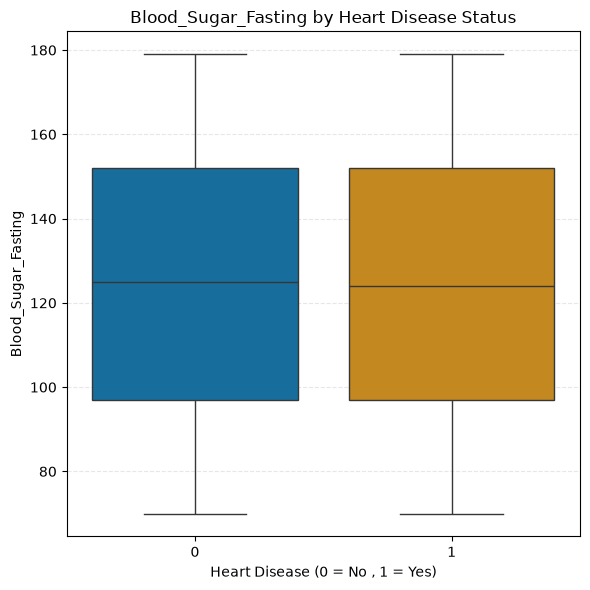

Mean 'Blood_Sugar_Fasting' for Heart_Disease categories: 
Heart_Disease
0    124.594662
1    124.375351
Name: Blood_Sugar_Fasting, dtype: float64 



In [26]:
plt.figure(figsize = (6,6))
sns.boxplot(data=df, x='Heart_Disease', y='Blood_Sugar_Fasting', palette='colorblind') # age grouped by Heart_Disease

plt.title('Blood_Sugar_Fasting by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No , 1 = Yes)') 

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("Mean 'Blood_Sugar_Fasting' for Heart_Disease categories: ")
print(df.groupby('Heart_Disease')['Blood_Sugar_Fasting'].agg("mean"),"\n")

Although Blood Sugar is usually one of the first thing to be thought of when discussing heart diesease,     
 it seems that it doesnt hold any correlation with the target class in this dataset.

####  Binary medical conditions vs Heart Disease:

- Hypertension,
- Diabetes,
- Hyperlipidemia,
- Family_History,
- Previous_Heart_Attack

**Why percentage method**       
Percentage mehod instead of count plot is used here because it better represents the risk among groups regardless of the size of the group sample.      
(if we have 10,000 non-smokers and 1000 smokers and use countplot, it will make non smokers look like they have way more heart disease only becuase of their bigger size).      

C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\2362936835.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x =disease_rate.index , y = disease_rate.values, edgecolor = 'black', palette='colorblind' )


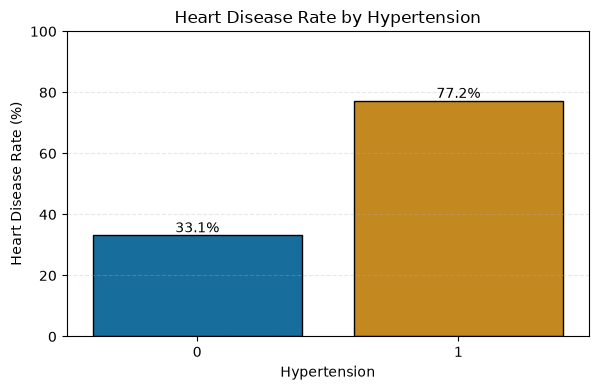

Hypertension
0    33.147720
1    77.197784
Name: 1, dtype: float64


C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\2362936835.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x =disease_rate.index , y = disease_rate.values, edgecolor = 'black', palette='colorblind' )


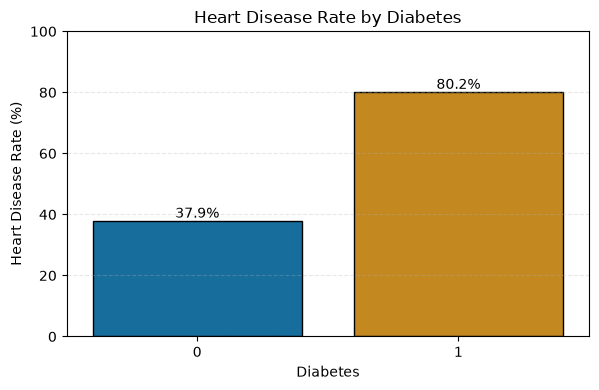

C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\2362936835.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x =disease_rate.index , y = disease_rate.values, edgecolor = 'black', palette='colorblind' )


Diabetes
0    37.932413
1    80.156579
Name: 1, dtype: float64


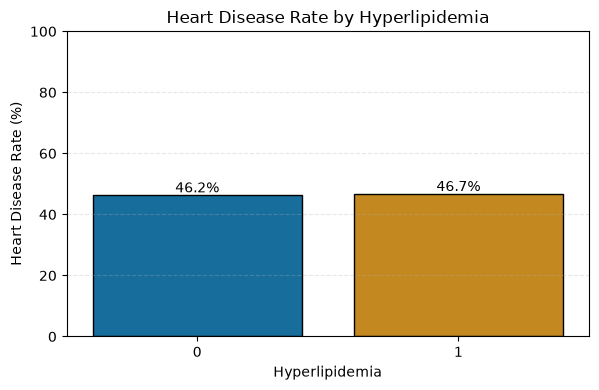

C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\2362936835.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x =disease_rate.index , y = disease_rate.values, edgecolor = 'black', palette='colorblind' )


Hyperlipidemia
0    46.235668
1    46.674084
Name: 1, dtype: float64


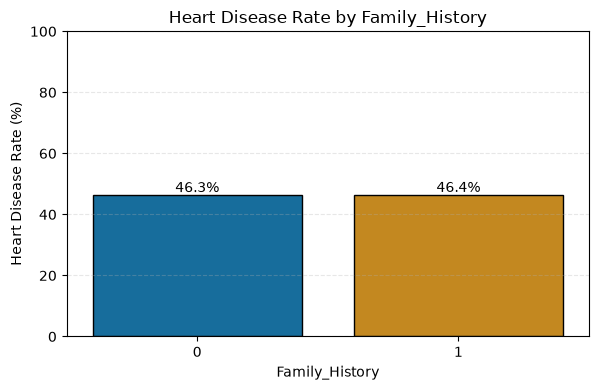

C:\Users\Masters Computer\AppData\Local\Temp\ipykernel_4512\2362936835.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x =disease_rate.index , y = disease_rate.values, edgecolor = 'black', palette='colorblind' )


Family_History
0    46.325271
1    46.377029
Name: 1, dtype: float64


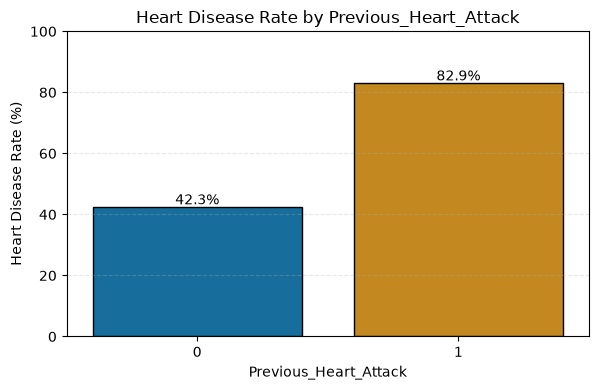

Previous_Heart_Attack
0    42.315037
1    82.917002
Name: 1, dtype: float64


In [55]:
# Calculating percentages(heart-disease rate) across categories 

# advanced way using pd.crosstab() 

# pd.crosstab(df[val], df['Heart_Disease'], normalize='index') * 100
# normalize='index' turns the counts into decimal proportions for each row, then * 100 makes it a percentage

binary_conditions = ['Hypertension', 'Diabetes', 'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack']

positive_heart_disease = 1 # represents having heart disease

for val in binary_conditions:
    plt.figure(figsize=(6,4))

    crosstab_data = pd.crosstab(df[val], df['Heart_Disease'], normalize= 'index') * 100
     
    disease_rate = crosstab_data[positive_heart_disease] #  the column only representing POSITIVE heart disease cases

    ax = sns.barplot(x =disease_rate.index , y = disease_rate.values, edgecolor = 'black', palette='colorblind' )

    for i, rate in enumerate(disease_rate.values):
        plt.text(i, rate + 1, f'{rate:.1f}%', ha='center')

    plt.title(f'Heart Disease Rate by {val}')
    plt.ylabel('Heart Disease Rate (%)')
    plt.xlabel(val)
    
    plt.grid(axis = 'y',linestyle = '--', alpha = .3 )
    plt.tight_layout()
    
    plt.ylim(0, 100) # keep the y axis out of 100 for all charts.
    
    plt.show()
    
    print(disease_rate)
    

### traditional way

# binary_conditions = ['Hypertension', 'Diabetes', 'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack']

# positive_heart_disease = 1 # represents having heart disease

# for val in binary_conditions:
#     plt.figure(figsize=(6,4))

#     proportions = df.groupby(val)['Heart_Disease'].value_counts(normalize= True).unstack() * 100 
    
#     disease_rate = proportions[positive_heart_disease]
    
#     sns.barplot(x = disease_rate.index, y= disease_rate.values, edgecolor = 'black', palette = 'colorblind' )
    
#     plt.title(f'Heart Disease Rate by {val}')
#     plt.ylabel('Heart Disease Rate (%)')
#     plt.xlabel(val)
    
#     plt.ylim(0, 100) # Keeps the y-axis consistent
    
#     print(proportions)
#     plt.show()


    

one instance is :   
Among people without hypertension, about 33% have heart disease.        
Among people with hypertension, about 77% have heart disease.       

patients with hypertension show a much higher heart-disease rate than patients without hypertension in this dataset.    

Some features that might initially appear relevant, such as Family_History and Hyperlipidemia,      
 showed little difference between the target classes in this synthetic dataset (Meaning that they are actually irrelevant).

#### Lifestyle Features (categorical) vs Heart disease: 

##### Smoking vs Heart disease:

Heart_Disease          0          1
Smoking                            
Current        53.818364  46.181636
Former         53.670886  46.329114
Never          53.594164  46.405836


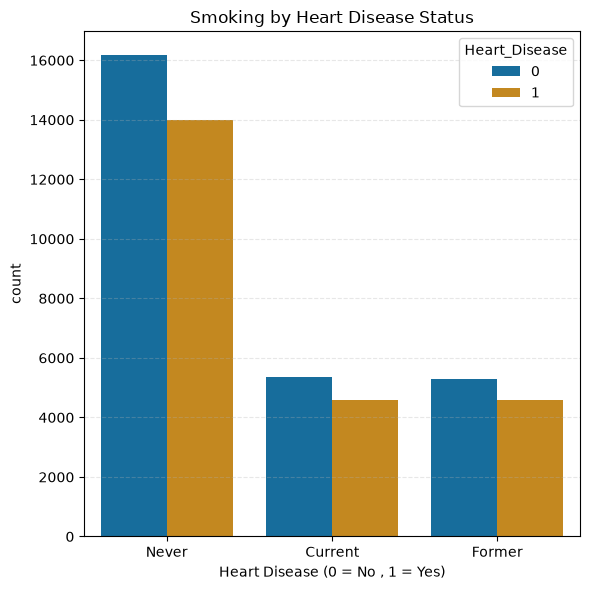

In [63]:
plt.figure(figsize = (6,6))
sns.countplot(data=df,  x='Smoking', hue= 'Heart_Disease', palette='colorblind') # age grouped by Heart_Disease

print (df.groupby(df['Smoking'])['Heart_Disease'].value_counts(normalize= True).unstack() * 100)

plt.title('Smoking by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No , 1 = Yes)') 

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

We can see that The percentages are almost identical accross the categories of Smoking activities, meaning tha it is relativly irregardable (has no effect) in this dataset.    
(`Smoking` shows little visible association with `Heart_Disease` in this dataset.)

##### Physical_Activity vs Heart Disease:

Heart_Disease              0          1
Physical_Activity                      
Active             53.392983  46.607017
Moderate           53.635490  46.364510
Sedentary          53.856868  46.143132


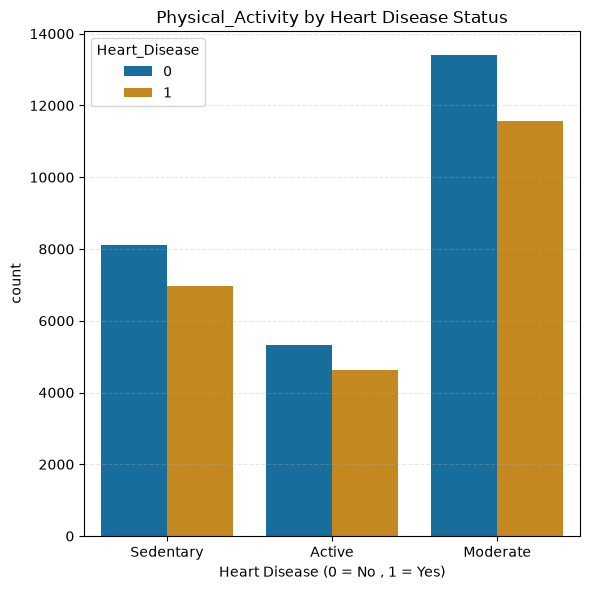

In [64]:
plt.figure(figsize = (6,6))
sns.countplot(data=df,  x='Physical_Activity', hue= 'Heart_Disease', palette='colorblind') # age grouped by Heart_Disease

print (df.groupby(df['Physical_Activity'])['Heart_Disease'].value_counts(normalize= True).unstack() * 100)

plt.title('Physical_Activity by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No , 1 = Yes)') 

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

We can see that The percentages are almost identical accross the categories of Physical_Activity, meaning tha it is relativly irregardable (has no effect) in this dataset.

### Correlation matrix

The correlation matrix is used to check linear relationships between the numerical features and the target.

A value closer to 1 or -1 means a stronger linear relationship, while a value closer to 0 means a weaker linear relationship.

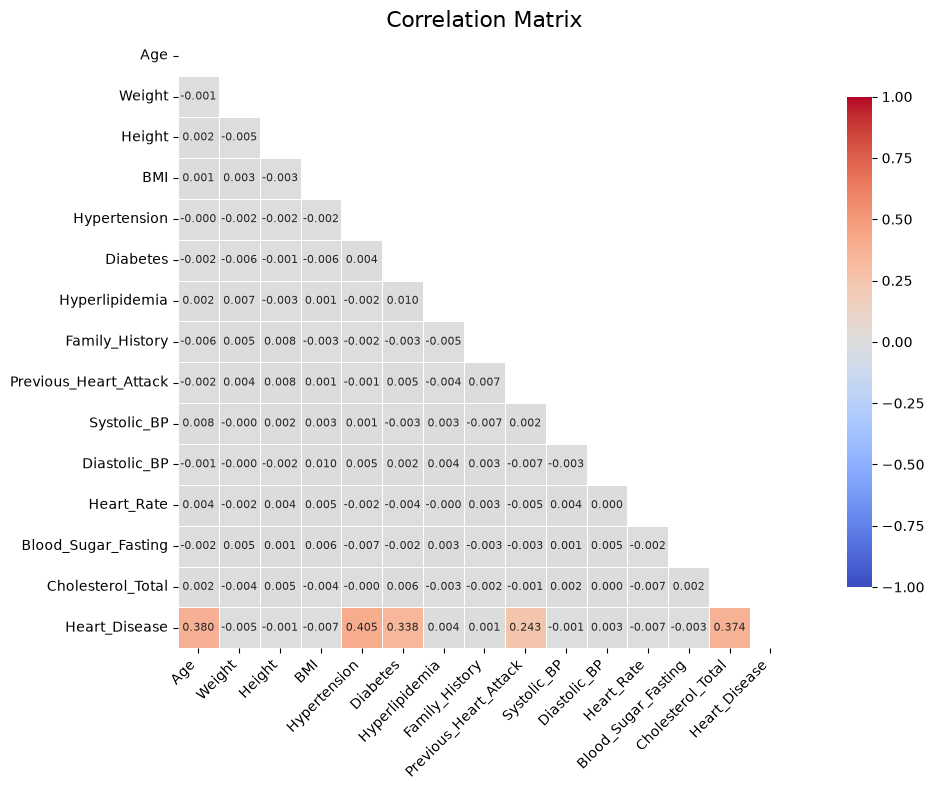

In [66]:
corr = df.corr(numeric_only=True) # correlation for the dataset but we drop the patient id

mask = np.triu(np.ones_like(corr, dtype=bool)) # show only the bottom half

plt.figure(figsize=(12, 8))

sns.heatmap(corr,
    mask=mask,
    annot=True,
    fmt='.3f',             
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Matrix', fontsize=16)
plt.xticks(rotation=45, ha='right') # rotates the X labels so they become readable
plt.tight_layout()
plt.show()

Hypertension, age, total cholesterol, diabetes, and previous heart attack appear to be the variables most strongly associated with the target.

Since we have 50,000 rows of data, scatter-plots arent really clear nor readable. so There will be no feature vs feature relations plots.

### Potential Outliers:

Boxplots are used to check for values that fall far outside the main range of the data.

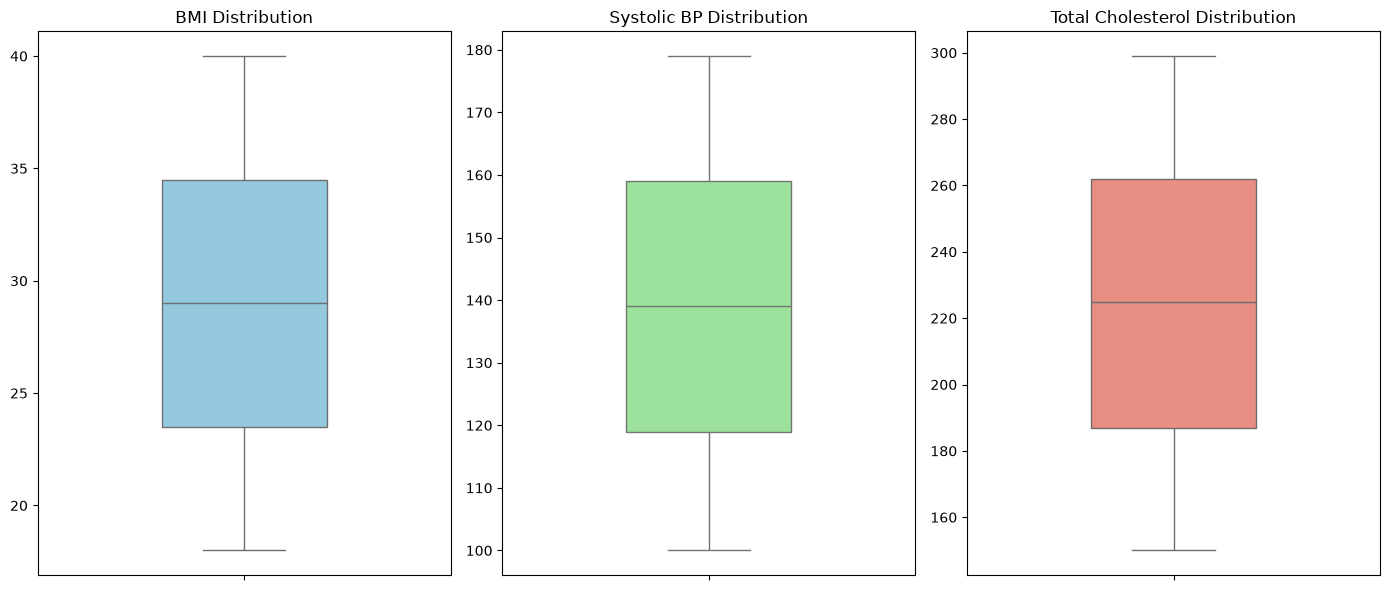

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# Plot 1
sns.boxplot(data=df, y='BMI', ax=axes[0], color='skyblue', width=0.4)
axes[0].set_title('BMI Distribution')
axes[0].set_ylabel('') # Cleans up the axis

# Plot 2
sns.boxplot(data=df, y='Systolic_BP', ax=axes[1], color='lightgreen', width=0.4)
axes[1].set_title('Systolic BP Distribution')
axes[1].set_ylabel('')

# Plot 3
sns.boxplot(data=df, y='Cholesterol_Total', ax=axes[2], color='salmon', width=0.4)
axes[2].set_title('Total Cholesterol Distribution')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

we dont have outliers in these columns since there are no dots outside the whiskers.

### EDA Findings \ Results:  

- The target is reasonably balanced: about 54% class 0 and 46% class 1.
- `Age` is clearly higher on average for the heart-disease group.
- `Cholesterol_Total` is also noticeably higher for the heart-disease group.
- `Hypertension`, `Diabetes`, and `Previous_Heart_Attack` show strong differences in heart-disease rate.
- `BMI` and `Blood_Sugar_Fasting` show very little direct difference between the target classes.
- `Family_History`, `Hyperlipidemia`, `Smoking`, and `Physical_Activity` also show little direct association with the target in this synthetic dataset.
- The correlation matrix supports the same main features: age, total cholesterol, hypertension, diabetes, and previous heart attack.
- The checked numerical features do not show obvious extreme outliers.
- These findings will be useful when comparing supervised-learning models later.